![HydroCycle](images/hydro_5cycle.jpg)

# Retrieve and Analyze Hydrology data for a watershed of interest

To make predictions for reservoir operations, water supply, flood control, etc, we need to collect data to train/calibrate hydrologic models. This includes streamflow, current environmental conditions (e.g., snow water equivalent), and future weather predictions. This exercise will build on the previous SNOTEL module to work towards building a hydrologic module.

Need to find a station? Use the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/)


Click the link and explore!

# 1. Delineated Watershed Map Upstream of a NWIS Site
The following code uses the pynhd and folium packages to create an interactive map of a watershed from a USGS gauge ID.

In our exercise, we are tasked with identifying all SNOTEL sites upstream of Hetch Hetchy Reservoir on the Tuolumne River. The user can search for "USGS streamflow Tuolumne River" and serveral locations will pop up. Site [11274790](https://waterdata.usgs.gov/monitoring-location/11274790/#dataTypeId=continuous-00065-0&period=P7D&showMedian=false) is the site of interest for this assessment 

In [ ]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

Define the watershed outlet using NWIS site id. Create a map object that we'll add layers to.

In [ ]:
nldi = NLDI()
usgs_gage_id = "09330000" # NWIS id for the FREMONT RIVER NEAR BICKNELL, UT
WY = 2019 # Water Year to analyze. A water year is defined as the 12 month period from October 1st to September 30th.

## Get meterological information data for our area of interest using GEE and NLDAS2

We will be using the GEE python api to retrived NLDAS2 meteorological data from the [NLDAS Earth Engine Catalog](https://developers.google.com/earth-engine/datasets/catalog/NASA_NLDAS_FORA0125_H002).

![GEE_NLDAS](images/NASA_NLDAS_FORA0125_H002_sample.png)


In [38]:
# Get geometry and ensure CRS is correct
basin = NLDI().get_basins(usgs_gage_id) #get basin information, we could load the files that we saved too
geometry = basin.to_crs("EPSG:4326").geometry[0] # Get the bounding box of the geometry
basin_polygon_coords = list(geometry.exterior.coords)

In [39]:
#we can get hourly data  but it can take a long time and crash if the start and end date are too far apart
hourly_NLDAS_df = getData.get_NLDAS_hourly(basin_polygon_coords)
hourly_NLDAS_df.head()



Authenticating with Earth Engine...
Initializing Earth Engine...
Earth Engine initialized successfully.


,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2025-12-30T00:00:00,0,175.279458,0,0.124794,74363.515221,11.555812,0.001313,-2.079786,0,-0.229250,-0.733938
2025-12-30T01:00:00,0,175.273753,0,0.020696,74397.092450,0.000000,0.001381,-2.547281,0,-0.106819,-0.759008
2025-12-30T02:00:00,0,175.267525,0,0.020696,74430.654153,0.000000,0.001449,-3.016645,0,0.014835,-0.785345
2025-12-30T03:00:00,0,175.733510,0,0.020696,74464.193919,0.000000,0.001517,-3.485282,0,0.136622,-0.809075
2025-12-30T04:00:00,0,175.732291,0,0.021126,74460.914994,0.000000,0.001511,-3.592348,0,0.220325,-0.977521


In [40]:
#It crashes if we try to get too much data at once, so we will get daily data for a smaller range of dates
Daily_NLDAS_df1 = getData.get_NLDAS_daily(basin_polygon_coords, begin_date='2006-01-01', end_date='2012-01-1')
Daily_NLDAS_df1.head()

Authenticating with Earth Engine...
Initializing Earth Engine...
Earth Engine initialized successfully.


,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2006-01-01,0.068364,214.945984,10.357649,0.054106,72753.678503,107.852158,0.003055,-3.338389,0.091463,3.342801,0.910459
2006-01-02,0.000000,254.142714,0.084665,0.067265,73029.484303,91.486908,0.003090,-2.143214,0.161195,-0.559634,4.033410
2006-01-03,0.011927,242.204453,9.225596,0.067936,73256.813998,107.238005,0.003487,-1.811355,0.107383,2.769881,3.616136
2006-01-04,0.000000,197.144062,0.000000,0.024668,74239.713135,109.932230,0.002689,-4.391122,0.012684,1.648244,-0.040291
2006-01-05,0.000000,182.991867,0.000000,0.023489,74969.586306,112.016637,0.002074,-4.712330,0.000000,1.480716,-1.937328


In [41]:
#It crashes if we try to get too much data at once, so we will get daily data for a smaller range of dates
Daily_NLDAS_df_2 = getData.get_NLDAS_daily(basin_polygon_coords, begin_date='2012-01-1', end_date='2018-01-1')
Daily_NLDAS_df_2.head()

Authenticating with Earth Engine...
Initializing Earth Engine...
Earth Engine initialized successfully.


,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2012-01-01,0.0,175.317943,0.0,0.043957,74389.470457,109.030771,0.001155,-4.667959,0.0,0.081822,-0.558455
2012-01-02,0.0,190.995285,0.0,0.039480,74712.288553,109.286670,0.001643,-1.237315,0.0,-0.740175,0.180954
2012-01-03,0.0,192.753042,0.0,0.053759,74620.154296,107.145735,0.001624,-0.002920,0.0,0.408566,0.247697
2012-01-04,0.0,184.589639,0.0,0.035818,74777.246244,110.945184,0.001788,-0.652630,0.0,0.532499,-1.118524
2012-01-05,0.0,192.697172,0.0,0.036914,74511.686009,110.110180,0.001602,0.344281,0.0,0.538491,-0.121633


In [42]:
#It crashes if we try to get too much data at once, so we will get daily data for a smaller range of dates
Daily_NLDAS_df_3 = getData.get_NLDAS_daily(basin_polygon_coords, begin_date='2018-01-1', end_date='2022-01-1')
Daily_NLDAS_df_3.head()

Authenticating with Earth Engine...
Initializing Earth Engine...
Earth Engine initialized successfully.


,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2018-01-01,0.0,198.823185,0.0,0.065692,74043.572363,101.241868,0.002308,-0.483355,0.0,1.474492,-0.624291
2018-01-02,0.0,175.506529,0.0,0.084249,74245.108714,111.431051,0.001748,-1.955541,0.0,1.736017,-1.881512
2018-01-03,0.0,157.508289,0.0,0.069291,74152.145371,111.903182,0.000729,-1.906206,0.0,0.054652,-0.454372
2018-01-04,0.0,196.765520,0.0,0.073295,73950.082591,105.006496,0.001152,-0.193203,0.0,0.613430,-0.434191
2018-01-05,0.0,212.062405,0.0,0.064570,74163.945837,104.498314,0.002310,1.280142,0.0,0.502772,0.039818


In [43]:
#combine the three dataframes into one
Daily_NLDAS_df = pd.concat([Daily_NLDAS_df1, Daily_NLDAS_df_2, Daily_NLDAS_df_3], ignore_index=False)
#set 
Daily_NLDAS_df.head()

,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2006-01-01,0.068364,214.945984,10.357649,0.054106,72753.678503,107.852158,0.003055,-3.338389,0.091463,3.342801,0.910459
2006-01-02,0.000000,254.142714,0.084665,0.067265,73029.484303,91.486908,0.003090,-2.143214,0.161195,-0.559634,4.033410
2006-01-03,0.011927,242.204453,9.225596,0.067936,73256.813998,107.238005,0.003487,-1.811355,0.107383,2.769881,3.616136
2006-01-04,0.000000,197.144062,0.000000,0.024668,74239.713135,109.932230,0.002689,-4.391122,0.012684,1.648244,-0.040291
2006-01-05,0.000000,182.991867,0.000000,0.023489,74969.586306,112.016637,0.002074,-4.712330,0.000000,1.480716,-1.937328


In [44]:
Daily_NLDAS_df.tail()

,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2021-12-27,0.000000,215.585818,9.769874,0.039912,72529.989939,91.719391,0.002271,-7.786394,0.039017,1.786595,2.803826
2021-12-28,0.001721,242.981600,13.222718,0.037248,72055.041735,92.103976,0.002392,-8.281944,0.128825,2.207816,2.206172
2021-12-29,0.000425,214.188933,2.203079,0.023991,72149.819550,101.637543,0.002157,-10.105898,0.056440,1.884042,1.980355
2021-12-30,0.000000,238.938944,3.195529,0.028813,72578.753508,71.049166,0.002715,-6.970592,0.008458,1.922519,3.317903
2021-12-31,0.005718,246.012401,15.210306,0.029723,72184.182424,81.878491,0.003049,-5.630465,0.118558,2.192883,2.454171


## Data exploration

### Lets examine basin longwave and shortwave radiation

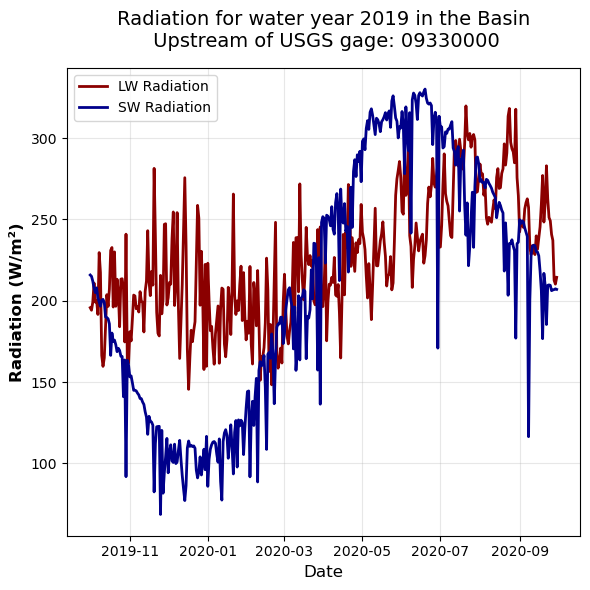

In [45]:
#For year 2019, plot all SWE_cm columns
met_df_2019 = Daily_NLDAS_df.loc['2019-10-01':'2020-09-30'].copy()
#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Radiation (W/m²)', color='black', fontsize=12, fontweight='bold')
ax1.plot(met_df_2019.index, met_df_2019['longwave_radiation'], linewidth=2, label = 'LW Radiation', color='darkred')
ax1.plot(met_df_2019.index, met_df_2019['shortwave_radiation'], linewidth=2, label = 'SW Radiation', color='darkblue')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3)

#show a legend
ax1.legend()

# Title and Layout
plt.title(f" Radiation for water year 2019 in the Basin \n Upstream of USGS gage: {usgs_gage_id}", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

### Lets look at temperature

In [46]:
met_df_2019.columns

Index(['convective_fraction', 'longwave_radiation', 'potential_energy',
       'potential_evaporation', 'pressure', 'shortwave_radiation',
       'specific_humidity', 'temperature', 'total_precipitation', 'wind_u',
       'wind_v'],
      dtype='object')

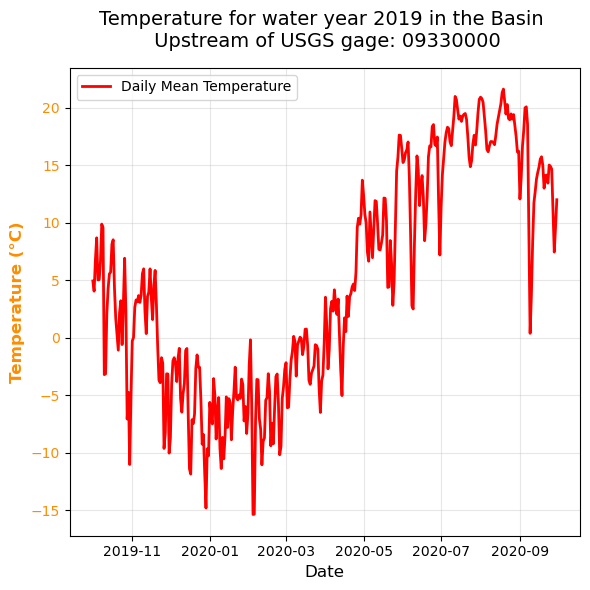

In [47]:
#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Temperature (°C)', color='darkorange', fontsize=12, fontweight='bold')
ax1.plot(met_df_2019.index, met_df_2019['temperature'], linewidth=2, label = 'Daily Mean Temperature', color='red')
ax1.tick_params(axis='y', labelcolor='darkorange')
ax1.grid(True, alpha=0.3)

#show a legend
ax1.legend()

# Title and Layout
plt.title(f"Temperature for water year 2019 in the Basin \n Upstream of USGS gage: {usgs_gage_id}", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

### Precipitation and temperature

Use a dual y-axies to plot both on the same plot. 

What insights can we make about the type of precipitation?

In [48]:
def align_yaxis(ax1, ax2):
    """Align zeros of the two axes by adjusting their limits."""
    # Get current limits
    y1_min, y1_max = ax1.get_ylim()
    y2_min, y2_max = ax2.get_ylim()

    # Calculate the ratio of the zero point relative to the total range
    # Example: If zero is exactly in the middle, ratio = 0.5
    y1_ratio = -y1_min / (y1_max - y1_min)
    y2_ratio = -y2_min / (y2_max - y2_min)

    # Adjust the axis with the smaller ratio to match the larger one
    if y1_ratio < y2_ratio:
        ax1.set_ylim(bottom=-y1_max * y2_ratio / (1 - y2_ratio))
    else:
        ax2.set_ylim(bottom=-y2_max * y1_ratio / (1 - y1_ratio))

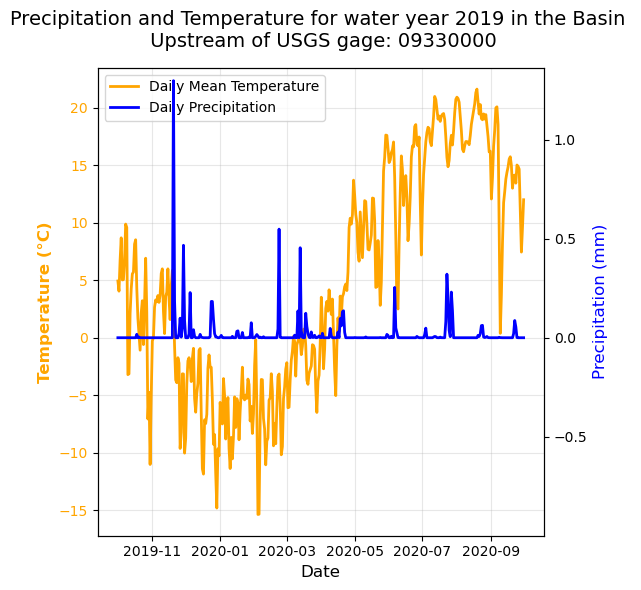

In [49]:
#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Temperature (°C)', color='orange', fontsize=12, fontweight='bold')
ax1.plot(met_df_2019.index, met_df_2019['temperature'], linewidth=2, label = 'Daily Mean Temperature', color='orange')
#ax1.plot(met_df_2019.index, met_df_2019['prcp_mm_day'], linewidth=2, label = 'Daily Precipitation', color='blue')
ax1.tick_params(axis='y', labelcolor='orange')
#make secondary y-axis for precipitation
ax2 = ax1.twinx()
ax2.plot(met_df_2019.index, met_df_2019['total_precipitation'], linewidth=2, label = 'Daily Precipitation', color='blue')
ax2.set_ylabel('Precipitation (mm)', color='blue', fontsize=12)
ax1.grid(True, alpha=0.3)
align_yaxis(ax1, ax2)

#Ask both axes for their handles and labels
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

#Combine them and create one legend
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


# Title and Layout
plt.title(f"Precipitation and Temperature for water year 2019 in the Basin \n Upstream of USGS gage: {usgs_gage_id}", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

### Plot wind

wind_u (Zonal Wind): Represents the east-west component. A positive value indicates wind blowing toward the east (from the west).

wind_v (Meridional Wind): Represents the north-south component. A positive value indicates wind blowing toward the north (from the south)

In [50]:
met_df_2019.columns


Index(['convective_fraction', 'longwave_radiation', 'potential_energy',
       'potential_evaporation', 'pressure', 'shortwave_radiation',
       'specific_humidity', 'temperature', 'total_precipitation', 'wind_u',
       'wind_v'],
      dtype='object')

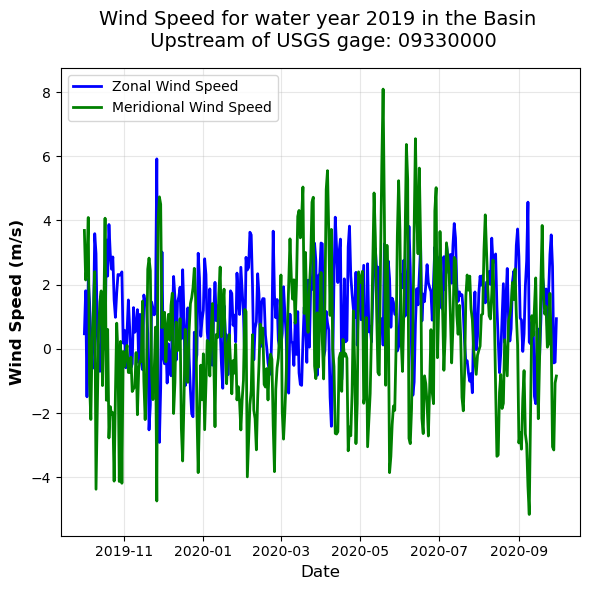

In [51]:
#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Wind Speed (m/s)', color='black', fontsize=12, fontweight='bold')
ax1.plot(met_df_2019.index, met_df_2019['wind_u'], linewidth=2, label = 'Zonal Wind Speed', color='blue')
ax1.plot(met_df_2019.index, met_df_2019['wind_v'], linewidth=2, label = 'Meridional Wind Speed', color='green')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3)

#show a legend
ax1.legend()

# Title and Layout
plt.title(f"Wind Speed for water year 2019 in the Basin \n Upstream of USGS gage: {usgs_gage_id}", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

### save the data for future use!

In [52]:
#save the cleaned dataframe to a csv file
# Use the getData module to retrieve data 
OutputFolder = 'files/NLDAS'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)
Daily_NLDAS_df.to_csv(f'{OutputFolder}/NLDAS_{usgs_gage_id}.csv')

## Exercise: Fetch a variable of your choice from Earth Engine

In this exercise, you are tasked with getting another variable from the [Google Earth Engine data catelog](https://developers.google.com/earth-engine/datasets/), something like the [MODIS Snow Covered Daily product](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD10A1). Add your function to your getData.py script and create a data processing function to bring to a daily resolution (if necessary) into dataprocessing.py. Plot you data either as a time series (as we have previously done) or over the basin for a single day.